# Plant Disease Detection - MobileNetV2 (Transfer Learning)

## 1. Imports

In [1]:
import os
import shutil
import json
import numpy as np
import cv2

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

2026-06-19 04:53:17.480474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781844797.704127      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781844797.768952      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781844798.328749      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781844798.328807      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781844798.328810      58 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"




## 4. Load Train/Val Datasets

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 24

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1781844845.939040      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781844845.944961      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes: 38


## 5. Performance Pipeline (cache, shuffle, prefetch)

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

## 6. Data Augmentation

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

## 7. Base Model (MobileNetV2)

In [6]:
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 8. Full Model (preprocessing baked inside the model graph)

In [7]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)      # active during training, automatically off during inference
x = preprocess_input(x)            # MobileNetV2 rescaling -> [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 9. Compile + Callbacks

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

## 10. Train (Frozen Base)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10


I0000 00:00:1781844967.451382     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7080 - loss: 1.0772
Epoch 1: val_accuracy improved from None to 0.89826, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 142s 52ms/step - accuracy: 0.8128 - loss: 0.6422 - val_accuracy: 0.8983 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 2/10
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8826 - loss: 0.3714
Epoch 2: val_accuracy improved from 0.89826 to 0.90876, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 108s 52ms/step - accuracy: 0.8835 - loss: 0.3657 - val_accuracy: 0.9088 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 3/10
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8926 - loss: 0.3288
Epoch 3: val_accuracy improved from 0.90876 to 0.90922, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 1

## 11. Fine-Tuning

In [11]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7712 - loss: 1.0236
Epoch 1: val_accuracy did not improve from 0.93481
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 144s 67ms/step - accuracy: 0.8367 - loss: 0.6146 - val_accuracy: 0.9322 - val_loss: 0.2242 - learning_rate: 1.0000e-05
Epoch 2/15
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8926 - loss: 0.3303
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_accuracy improved from 0.93481 to 0.93629, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 135s 67ms/step - accuracy: 0.8995 - loss: 0.3095 - val_accuracy: 0.9363 - val_loss: 0.2018 - learning_rate: 1.0000e-05
Epoch 3/15
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9133 - loss: 0.2629
Epoch 3: val_accuracy improved from 0.93629 to 0.94043, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━

## 12. Evaluation

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.92      0.92       126
                                 Apple___Black_rot       0.99      0.98      0.99       132
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        55
                                   Apple___healthy       0.95      1.00      0.97       329
                               Blueberry___healthy       1.00      0.98      0.99       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98       232
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.74      0.80       108
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       219
               Corn_(maize)___Northern_Leaf_Blight       0.86      0.94      0.

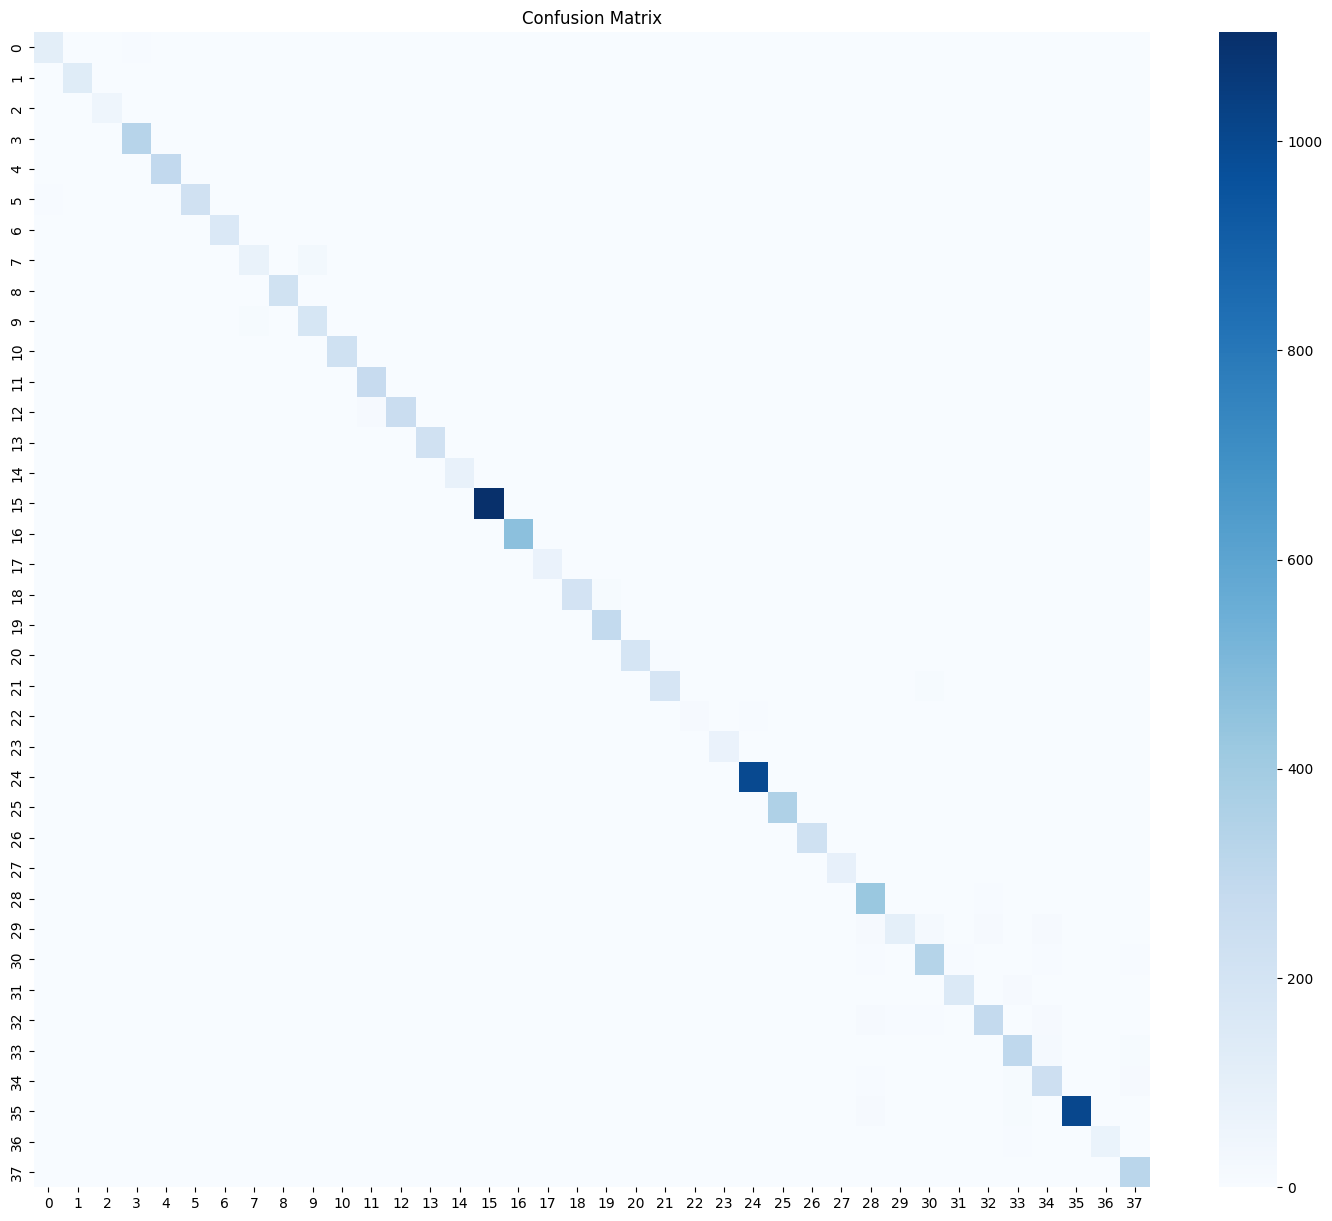

In [12]:
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18,15))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix")
plt.show()

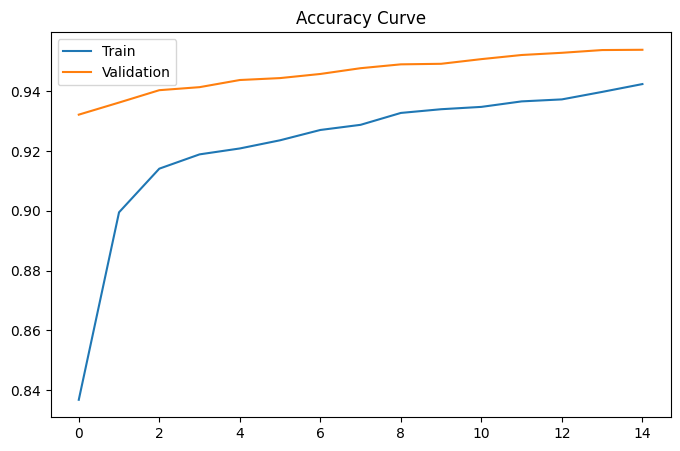

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])

plt.legend([
    'Train',
    'Validation'
])

plt.title("Accuracy Curve")

plt.show()

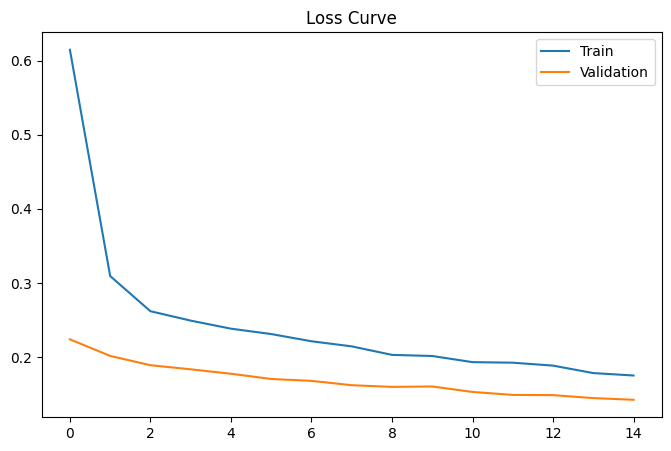

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])

plt.legend([
    'Train',
    'Validation'
])

plt.title("Loss Curve")

plt.show()

In [21]:
y_true = []
y_pred = []

for images, labels in val_ds:

    pred = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(pred,axis=1)
    )

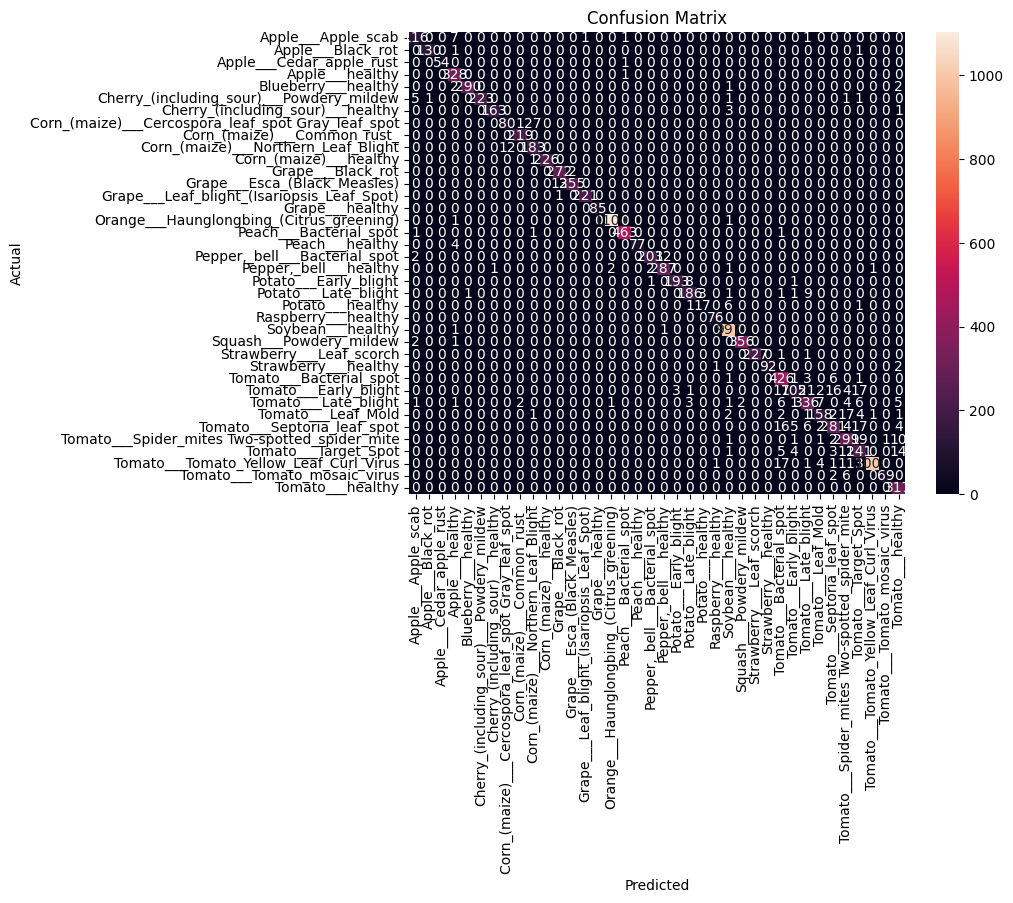

In [22]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
for images, labels in val_ds.take(1):

    plt.figure(figsize=(15,15))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        pred = model.predict(
            tf.expand_dims(images[i],0),
            verbose=0
        )

        pred_idx = np.argmax(pred)

        pred_class = class_names[pred_idx]

        actual_class = class_names[
            labels[i].numpy()
        ]

        result = "✓ Correct" if pred_class == actual_class else "✗ Wrong"

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            f"{result}\nActual: {actual_class}\nPred: {pred_class}"
        )

        plt.axis("off")

    plt.tight_layout()

plt.show()

## 13. Save Model + Class Names

In [17]:
import json

# Save model
model.save("/kaggle/working/plant_disease_mobilenetv2.keras")

# Save class names
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

## 14. Test on a Single Downloaded Image

In [ ]:
def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)        # OpenCV gives BGR, we need RGB
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img, axis=0).astype("float32")  # keep 0-255, model preprocesses internally

    preds = model.predict(img_array, verbose=0)
    idx = np.argmax(preds[0])
    confidence = preds[0][idx]

    print(f"Predicted: {class_names[idx]} ({confidence*100:.2f}%)")
    return class_names[idx], confidence

predict_image("/content/test_leaf.jpg", model, class_names)

## 15. Live Demo - Browser Camera Setup (Google Colab)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def start_camera():
    js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var labelElement;
    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
      stream.getVideoTracks()[0].stop();
      video.remove();
      div.remove();
      video = null;
      div = null;
      stream = null;
      captureCanvas = null;
      labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 320, 240);
          result = captureCanvas.toDataURL('image/jpeg', 0.8);
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) { return stream; }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '5px';
      document.body.appendChild(div);

      const statusBox = document.createElement('div');
      statusBox.innerHTML = "<b>Prediction:</b> ";
      labelElement = document.createElement('span');
      labelElement.innerText = 'Starting...';
      statusBox.appendChild(labelElement);
      div.appendChild(statusBox);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = 320;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia({video: true});
      div.appendChild(video);

      const note = document.createElement('div');
      note.innerHTML = '<span style="color:red;"><b>Click on the video to STOP</b></span>';
      div.appendChild(note);

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 320;
      captureCanvas.height = 240;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }

    async function takePhoto(label) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }
      stream = await createDom();
      if (label != "") { labelElement.innerText = label; }

      var result = await new Promise(function(resolve) {
        pendingResolve = resolve;
      });
      shutdown = false;
      return result;
    }
    ''')
    display(js)

def get_frame(label_text):
    data = eval_js(f'takePhoto("{label_text}")')
    return data

## 16. Live Demo - Prediction Loop

In [ ]:
start_camera()
label_text = "Starting..."

while True:
    frame_data = get_frame(label_text)

    if not frame_data:
        print("Camera stopped.")
        break

    # decode base64 -> image
    img_bytes = b64decode(frame_data.split(',')[1])
    frame = cv2.imdecode(np.frombuffer(img_bytes, dtype=np.uint8), cv2.IMREAD_COLOR)

    # preprocess (model already has preprocess_input baked in, so send raw 0-255 image)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
    input_arr = np.expand_dims(resized, axis=0).astype("float32")

    preds = model.predict(input_arr, verbose=0)
    idx = np.argmax(preds[0])
    confidence = preds[0][idx]

    label_text = f"{class_names[idx]} ({confidence*100:.1f}%)"